In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import matplotlib
from pathlib import Path

import os
os.chdir("./..")

# Loading dataset

In [19]:
alarms_path = Path("data/alarms/alarms-merged.csv")
alarms_raw = pd.read_csv(alarms_path, sep=";")
alarms = alarms_raw.copy()

alarms.head()

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms
0,35427,8a51c79fd40b6fc9be68e7aa3601e602,12,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,"[""52432""]"
1,71822,a6fa45504565dc0928efc8807db66487,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,"[""53292""]"
2,1746,c0ff722f9fac93e89919c7b09695dda5,3,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,"[""52080""]"
3,55540,066e25a0712b306a9b95230f6ec4a051,19,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,"[""52857""]"
4,54611,73dcb24720672b203e7c6763639860f3,18,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,"[""52700""]"


# Data Preparation

In [20]:
alarms.info()

<class 'pandas.DataFrame'>
RangeIndex: 76232 entries, 0 to 76231
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               76232 non-null  int64
 1   merged_id        76232 non-null  str  
 2   region_id        76232 non-null  int64
 3   region_title     76232 non-null  str  
 4   region_city      76232 non-null  str  
 5   all_region       76232 non-null  int64
 6   start            76232 non-null  str  
 7   end              76232 non-null  str  
 8   original_alarms  76232 non-null  str  
dtypes: int64(3), str(6)
memory usage: 16.0 MB


In [21]:
alarms['start'] = pd.to_datetime(alarms['start'])
alarms['end'] = pd.to_datetime(alarms['end'])
alarms['duration_min'] = (alarms['end'] - alarms['start']).dt.total_seconds() / 60

alarms['start_hour'] = alarms['start'].dt.hour
alarms['day_of_week'] = alarms['start'].dt.day_name().str.lower()
alarms['date'] = alarms['start'].dt.date
alarms['month_year'] = alarms['start'].dt.to_period('M').astype(str)

alarms = alarms[(alarms['duration_min'] > 0) & (alarms['duration_min'] <= 1440)]

display(alarms[['duration_min', 'start_hour']].describe())

,duration_min,start_hour
count,76147.000000,76147.000000
mean,88.740060,12.159428
std,123.851469,6.838189
min,0.050000,0.000000
25%,26.650000,7.000000
50%,42.733333,12.000000
75%,100.216667,18.000000
max,1439.066667,23.000000


- removed negative durations and extreme outliers (duration > 24 hours).
- data is now clean and ready for exploration.

# EDA
## Top 15 regions by number of alarms

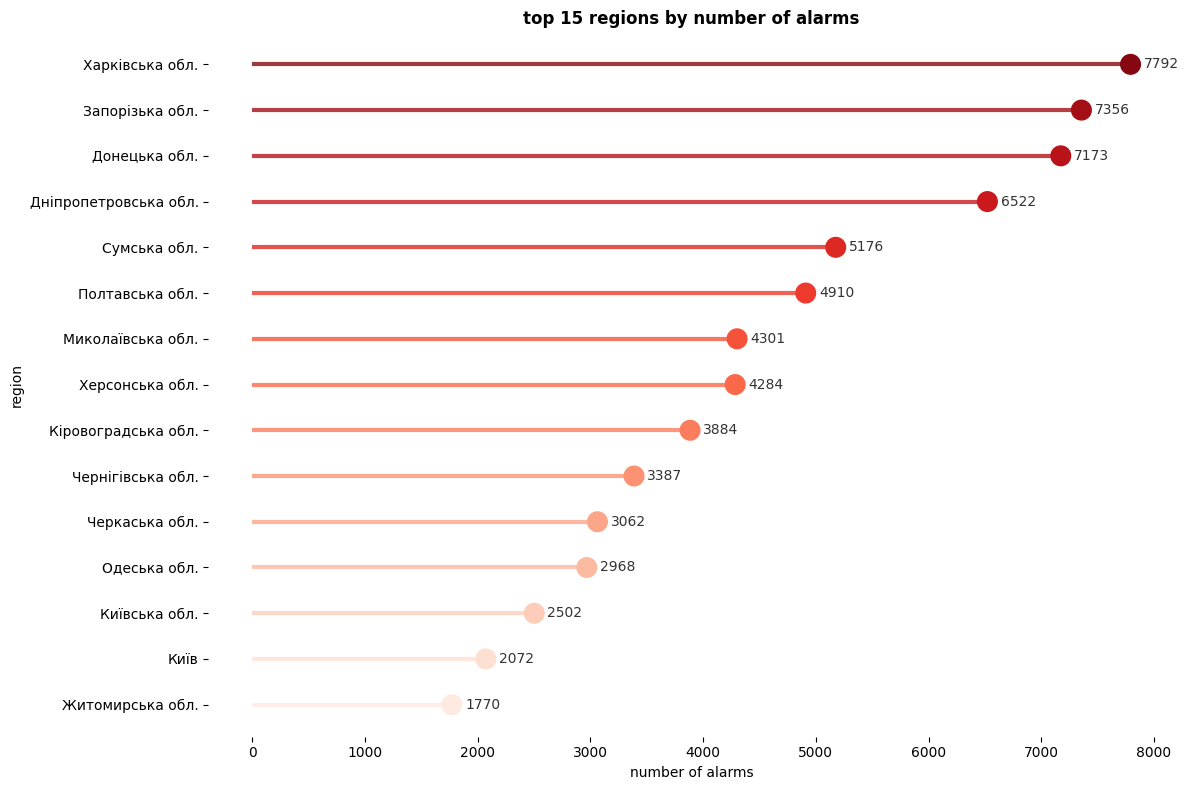

In [22]:
plt.figure(figsize=(12, 8))
alarms_by_region = alarms['region_city'].value_counts().head(15)

alarms_by_region = alarms_by_region.sort_values(ascending=True)

colors = sns.color_palette("Reds", len(alarms_by_region))

plt.hlines(
    y=alarms_by_region.index, 
    xmin=0, 
    xmax=alarms_by_region.values, 
    color=colors, 
    linewidth=3, 
    alpha=0.8
)

plt.scatter(
    alarms_by_region.values, 
    alarms_by_region.index, 
    color=colors, 
    s=200, 
    alpha=1, 
    zorder=3
)

for i, (value, name) in enumerate(zip(alarms_by_region.values, alarms_by_region.index)):
    plt.text(value + (max(alarms_by_region.values)*0.015), i, f"{value}", 
             va='center', color='#333333')

plt.title("top 15 regions by number of alarms", fontweight='bold')
plt.xlabel("number of alarms")
plt.ylabel("region")


sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

- eastern and southern regions are the most targeted ones.

## Distribution of alarm durations

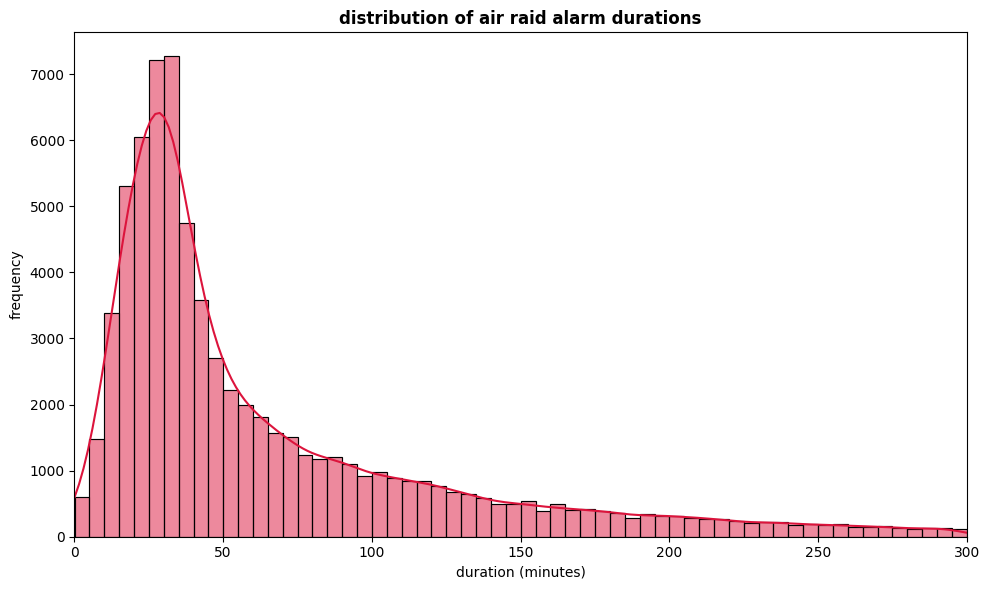

In [23]:
plt.figure(figsize=(10, 6))

alarms_filtered = alarms[alarms['duration_min'] <= 300]

sns.histplot(
    data=alarms_filtered, 
    x='duration_min', 
    bins=60, 
    kde=True, 
    color='crimson'
)

plt.title("distribution of air raid alarm durations",fontweight='bold')
plt.xlabel("duration (minutes)")
plt.ylabel("frequency")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

- most alarms last between 20 and 40 minutes.
- strong right-skewed distribution.

## Daily alarms count with spikes (extreme days)

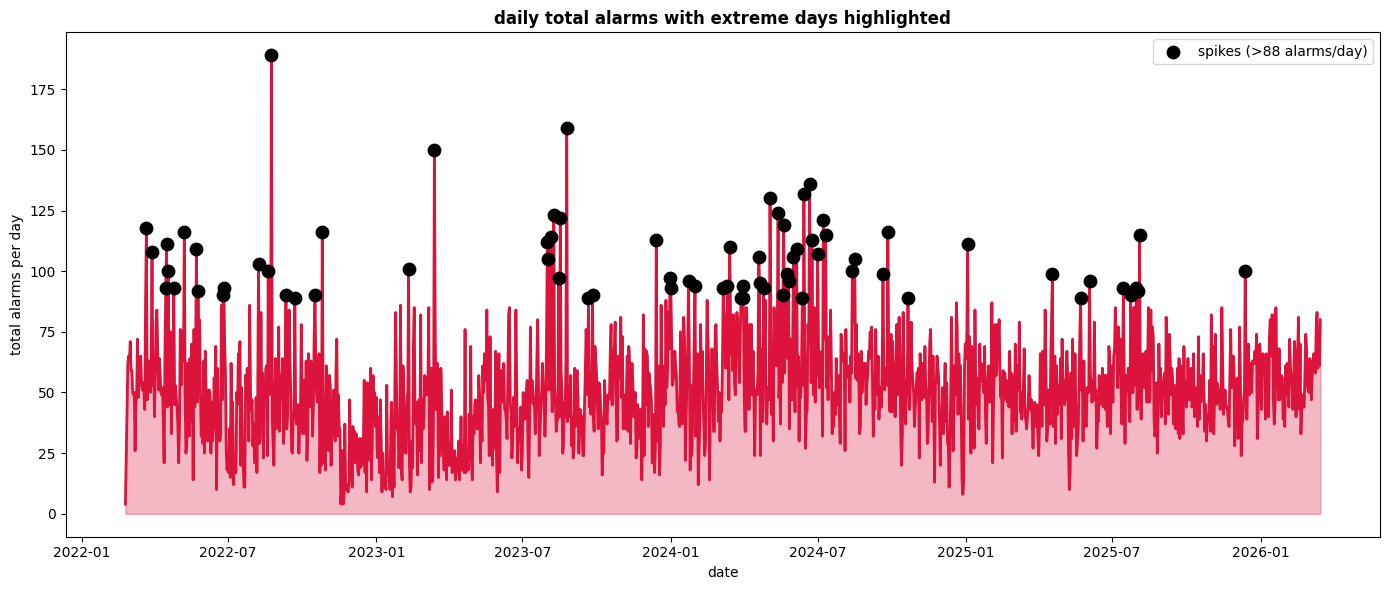

In [24]:
daily_alarms = alarms.groupby('date').size().reset_index(name='alarm_count')
daily_alarms['date'] = pd.to_datetime(daily_alarms['date'])

plt.figure(figsize=(14, 6))

plt.plot(daily_alarms['date'], daily_alarms['alarm_count'], linewidth=2, color='crimson')
plt.fill_between(daily_alarms['date'], daily_alarms['alarm_count'], alpha=0.3, color='crimson')

spike_threshold = daily_alarms['alarm_count'].quantile(0.95)
spikes = daily_alarms[daily_alarms['alarm_count'] > spike_threshold]

plt.scatter(spikes['date'], spikes['alarm_count'], color='black', s=80, zorder=5, 
            label=f'spikes (>{int(spike_threshold)} alarms/day)')

plt.title("daily total alarms with extreme days highlighted", fontweight='bold')
plt.xlabel("date")
plt.ylabel("total alarms per day")
plt.legend()
plt.tight_layout()
plt.show()

- black dots indicate massive attacks across the country.

## Heatmap: concentration of alarms (day of week vs hour)

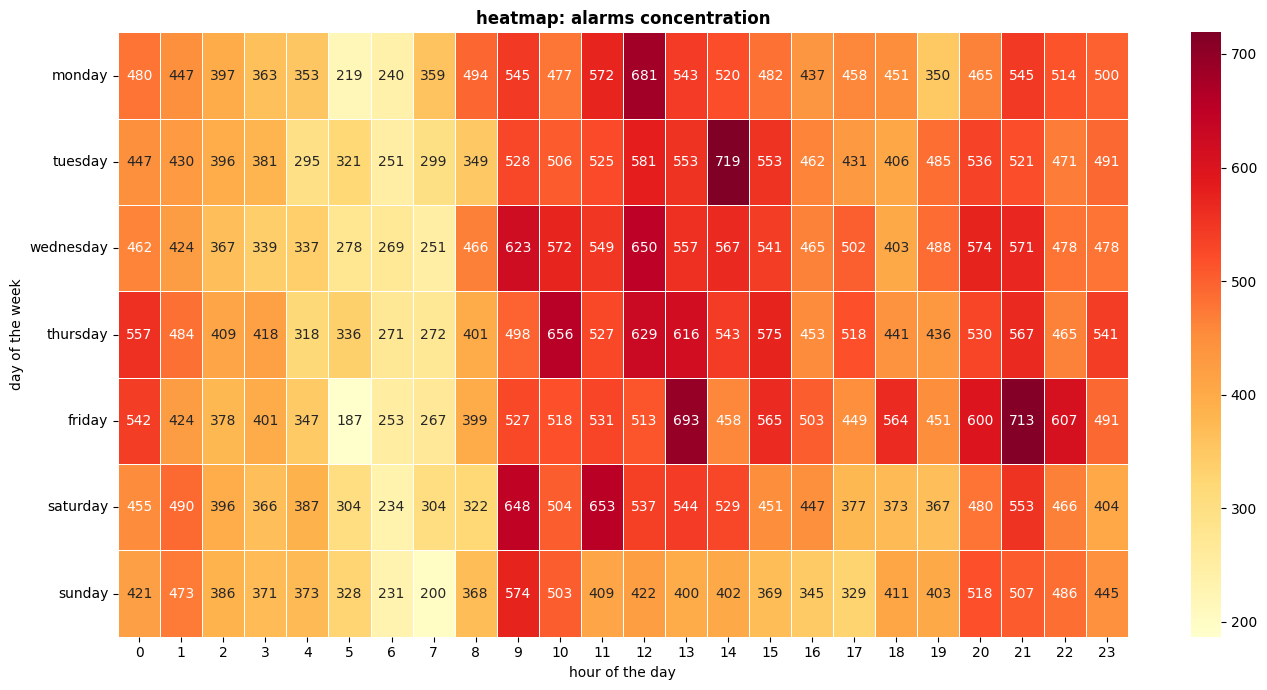

In [25]:
plt.figure(figsize=(14, 7))

pivot_alarms = alarms.pivot_table(index='day_of_week', columns='start_hour', aggfunc='size', fill_value=0)
days_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
pivot_alarms = pivot_alarms.reindex(days_order)

sns.heatmap(pivot_alarms, cmap='YlOrRd', linewidths=.5, annot=True, fmt="")

plt.title("heatmap: alarms concentration", fontweight='bold')
plt.xlabel("hour of the day")
plt.ylabel("day of the week")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- higher concentration of alarms can be observed during daytime and late evening.

## Boxen plot: alarm duration distribution by top regions

C:\Users\Георгій\AppData\Local\Temp\ipykernel_4184\2769895102.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


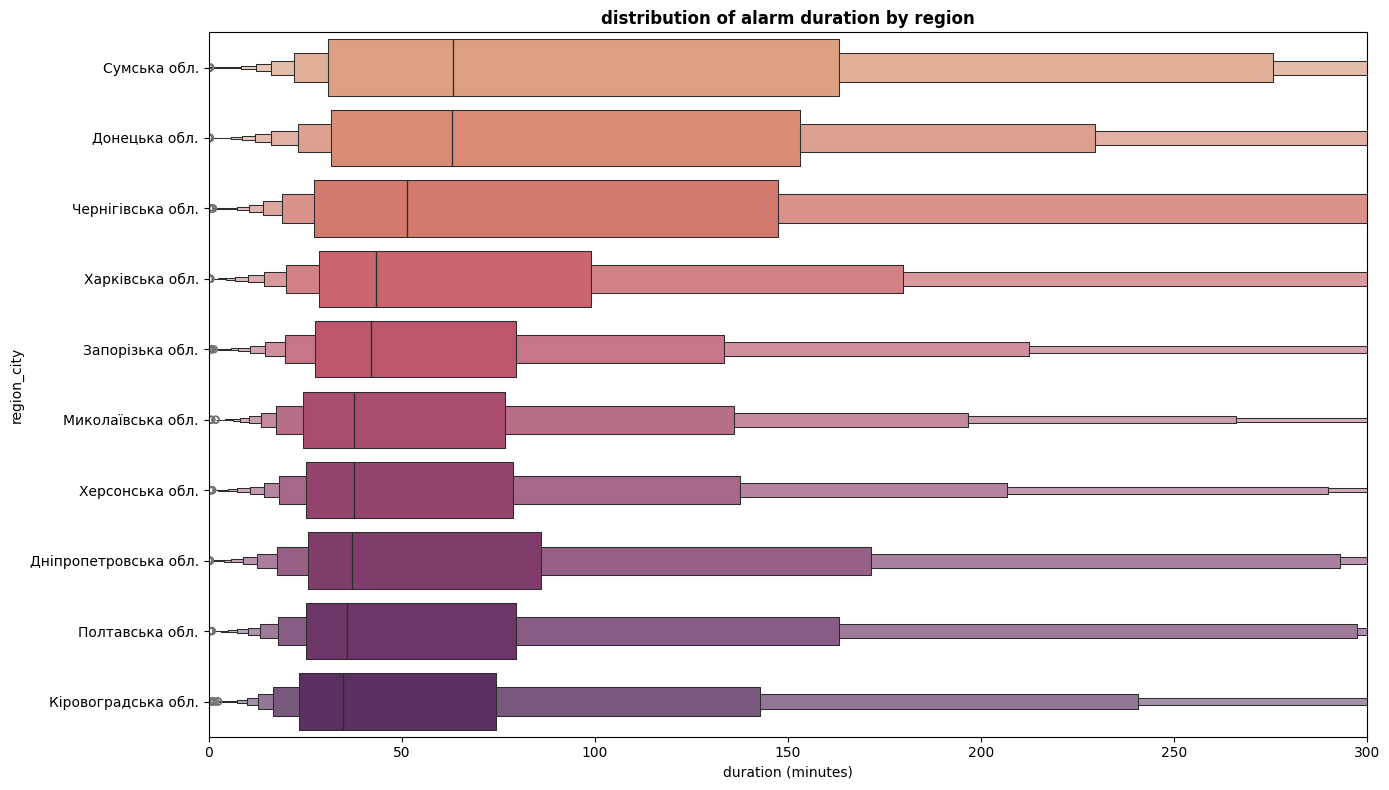

In [26]:
plt.figure(figsize=(14, 8))
top_10_regions = alarms['region_city'].value_counts().head(10).index
alarms_top_10 = alarms[alarms['region_city'].isin(top_10_regions)].copy()

order = alarms_top_10.groupby('region_city')['duration_min'].median().sort_values(ascending=False).index

sns.boxenplot(
    data=alarms_top_10,
    x='duration_min',
    y='region_city',
    order=order,
    palette='flare'
)

plt.title("distribution of alarm duration by region", fontweight='bold')
plt.xlabel("duration (minutes)")
plt.xlim(0, 300)

plt.tight_layout()
plt.show()

- boxen plot shows that while medians are similar, the tail of long alarms varies by region.
- southern regions tend to have a wider spread of long durations.

## Treemap of top 20 regions by alarm frequency

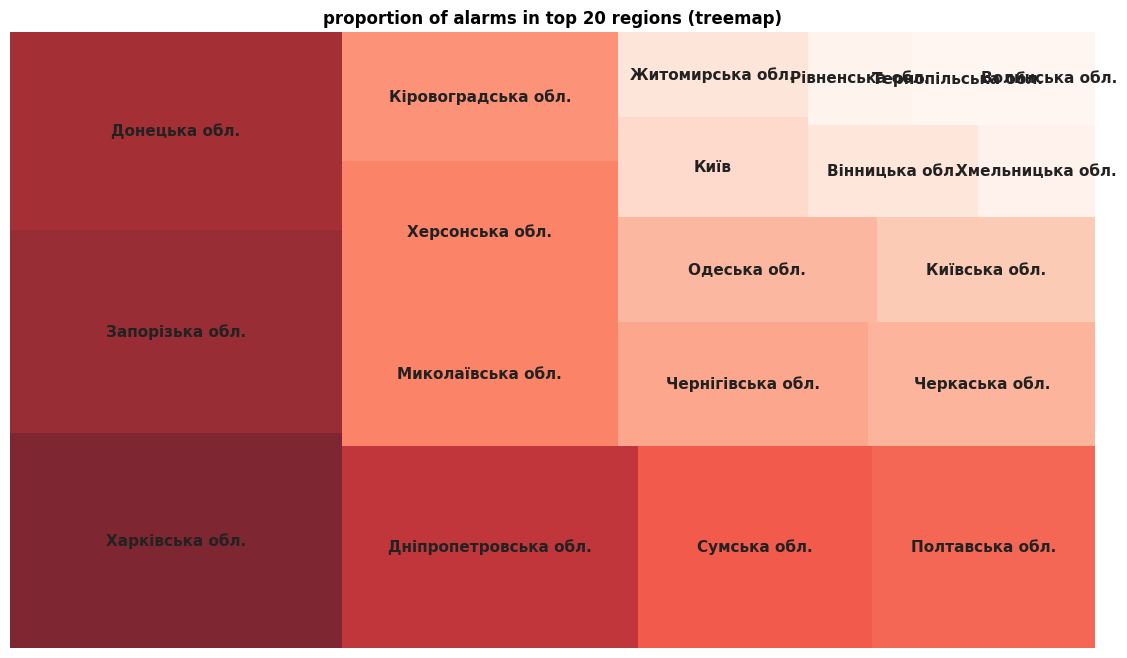

In [27]:
plt.figure(figsize=(14, 8))
region_counts = alarms['region_city'].value_counts().head(20)

cmap = matplotlib.colormaps['Reds']
mini, maxi = region_counts.min(), region_counts.max()
norm = matplotlib.colors.Normalize(vmin=mini, vmax=maxi)
colors = [cmap(norm(value)) for value in region_counts.values]

squarify.plot(
    sizes=region_counts.values, 
    label=region_counts.index, 
    color=colors, 
    alpha=0.85, 
    text_kwargs={'fontsize': 11, 'weight': 'bold', 'color': '#222222'}
)

plt.title("proportion of alarms in top 20 regions (treemap)", fontweight='bold')
plt.axis('off')
plt.show()

- treemap perfectly visualizes the overwhelming share of alarms in donetsk, kharkiv and zaporizhzhia regions compared to others.

## Overall trend: 14-day moving average

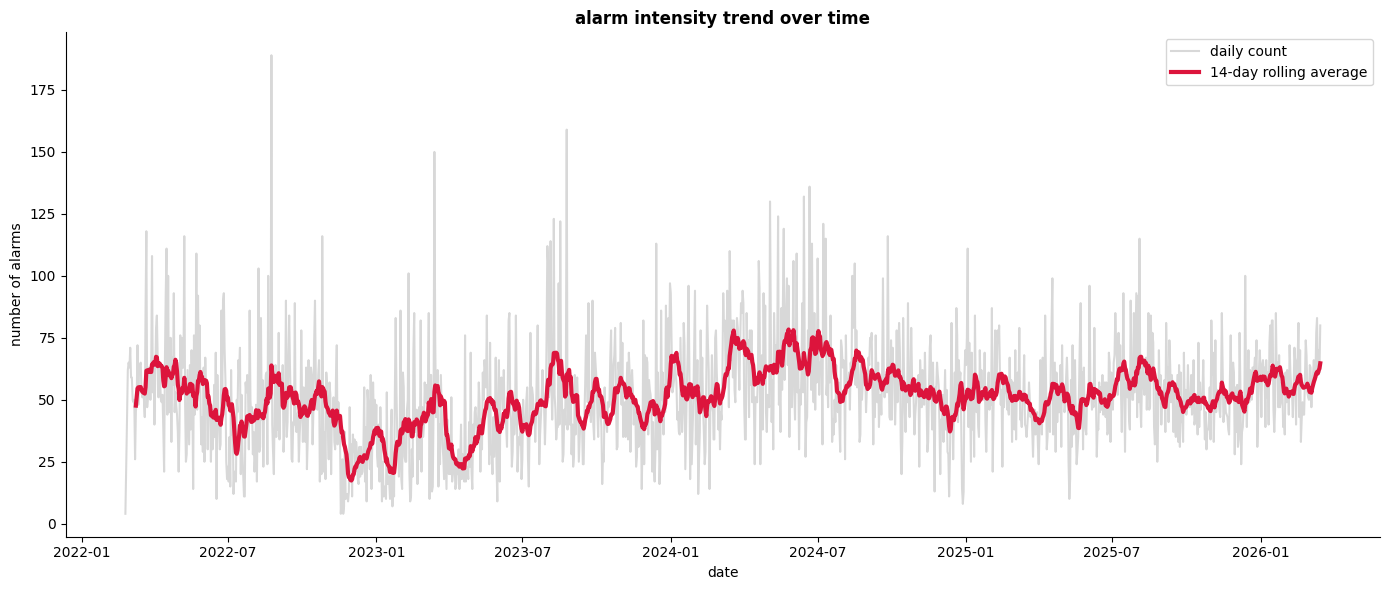

In [28]:
daily_alarms = alarms.groupby('date').size().reset_index(name='alarm_count')
daily_alarms['date'] = pd.to_datetime(daily_alarms['date'])
daily_alarms = daily_alarms.sort_values('date')

daily_alarms['rolling_avg'] = daily_alarms['alarm_count'].rolling(window=14).mean()

plt.figure(figsize=(14, 6))

plt.plot(daily_alarms['date'], daily_alarms['alarm_count'], color='grey', alpha=0.3, label='daily count')

plt.plot(daily_alarms['date'], daily_alarms['rolling_avg'], color='crimson', linewidth=3, label='14-day rolling average')

plt.title("alarm intensity trend over time", fontweight='bold')
plt.xlabel("date")
plt.ylabel("number of alarms")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

- the 14-day moving average smooths out daily noise and clearly highlights periods of major escalations.

# Data Preparation
## What I already did in EDA
- formatted `start` and `end` datetime columns
- calculated `duration_min` for each alarm
- extracted useful time features: `start_hour`, `day_of_week`, `date`
- removed anomalies (negative durations and false alarms lasting > 24 hours)

## Check for duplicates

In [29]:
# checking if there are fully identical rows in our dataset
alarms.duplicated().any()

np.False_

Check exact number of duplicates

In [30]:
print(f"number of exact duplicates: {alarms.duplicated().sum()}")

number of exact duplicates: 0


In [31]:
# removing duplicates
alarms.drop_duplicates(keep="last", inplace=True)
print(f"dataset shape after dropping duplicates: {alarms.shape}")

dataset shape after dropping duplicates: (76147, 14)


## Droping columns

In [32]:
alarms = alarms.drop(columns=["id", "merged_id", "original_alarms", "duration_min", "date", "month_year", "day_of_week"])

In [33]:
alarms["start_minute"] = alarms.start.dt.minute

In [34]:
alarms.head(3)

,region_id,region_title,region_city,all_region,start,end,start_hour,start_minute
0,12,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,7,43
1,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,14,0
2,3,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,15,40


In [36]:
alarms.region_id.nunique()

23

In [39]:
alarms.region_city.nunique()

24

In [40]:
alarms.loc[alarms.region_id == 11]

,region_id,region_title,region_city,all_region,start,end,start_hour,start_minute


In [41]:
alarms.loc[alarms.region_city == "Кіровоградська обл."]

,region_id,region_title,region_city,all_region,start,end,start_hour,start_minute
117,10,Кіровоградська область,Кіровоградська обл.,1,2022-02-27 20:01:14,2022-02-27 20:32:07,20,1
201,10,Кіровоградська область,Кіровоградська обл.,1,2022-03-01 05:47:33,2022-03-01 05:52:44,5,47
210,10,Кіровоградська область,Кіровоградська обл.,1,2022-03-01 09:33:31,2022-03-01 10:09:55,9,33
218,10,Кіровоградська область,Кіровоградська обл.,1,2022-03-01 10:53:26,2022-03-01 16:10:16,10,53
256,10,Кіровоградська область,Кіровоградська обл.,1,2022-03-01 22:15:44,2022-03-01 23:10:00,22,15
...,...,...,...,...,...,...,...,...
76100,10,Кіровоградська область,Кіровоградська обл.,1,2026-03-15 03:39:30,2026-03-15 04:32:32,3,39
76108,10,Кіровоградська область,Кіровоградська обл.,1,2026-03-15 07:26:05,2026-03-15 07:37:07,7,26
76119,10,Кіровоградська область,Кіровоградська обл.,1,2026-03-15 09:53:10,2026-03-15 12:14:22,9,53
76172,10,Кіровоградська область,Кіровоградська обл.,1,2026-03-16 09:09:04,2026-03-16 09:26:36,9,9


In [43]:
alarms.loc[alarms.region_city == "Чернігівська обл."]

,region_id,region_title,region_city,all_region,start,end,start_hour,start_minute
1,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,14,0
7,23,Чернігівська область,Чернігівська обл.,1,2022-02-25 06:46:43,2022-02-25 06:52:43,6,46
10,23,Чернігівська область,Чернігівська обл.,1,2022-02-25 11:11:43,2022-02-25 11:50:43,11,11
15,23,Чернігівська область,Чернігівська обл.,1,2022-02-25 13:54:43,2022-02-25 14:40:43,13,54
35,23,Чернігівська область,Чернігівська обл.,1,2022-02-26 09:20:43,2022-02-26 09:48:43,9,20
...,...,...,...,...,...,...,...,...
76154,23,Чернігівська область,Чернігівська обл.,1,2026-03-16 02:06:23,2026-03-16 02:34:20,2,6
76159,23,Чернігівська область,Чернігівська обл.,1,2026-03-16 03:03:45,2026-03-16 05:45:50,3,3
76167,23,Чернігівська область,Чернігівська обл.,1,2026-03-16 07:20:51,2026-03-16 09:57:21,7,20
76179,23,Чернігівська область,Чернігівська обл.,1,2026-03-16 10:03:22,2026-03-16 19:29:14,10,3


# Saving data

In [18]:
save_path = Path("data/alarms/alarms_data_preprocessed_v2.csv")

alarms.to_csv(save_path, index=False)

## Conclusions

### Data Preparation

- formatted the start and end times to calculate the exact duration of each alarm
- cleaned the dataset by removing anomalies, such as negative durations and false alarms lasting over 24 hours
- extracted useful time features like hour, day of the week, and date for deeper analysis
- dropped all duplicate alarm records to ensure data integrity

### Exploratory Data Analysis

- found that eastern and southern regions (donetsk, kharkiv, zaporizhzhia) take the overwhelming share of all alarms
- noticed that most alarms last between 20 and 40 minutes, but southern regions have a much wider spread of long-lasting alarms
- observed massive spikes in the daily number of alarms on specific dates, which clearly indicate large-scale attacks
- found that alarms are not entirely random in time: there is a higher concentration during daytime and late evening hours